# GitHub Copilot user prompt process flow

In this unit, we'll break down how GitHub Copilot turns your prompts into smart, usable code. Generally, GitHub Copilot receives prompts and returns code suggestions or responses in its data flow. This process suggests an inbound and outbound flow.

## Inbound flow:

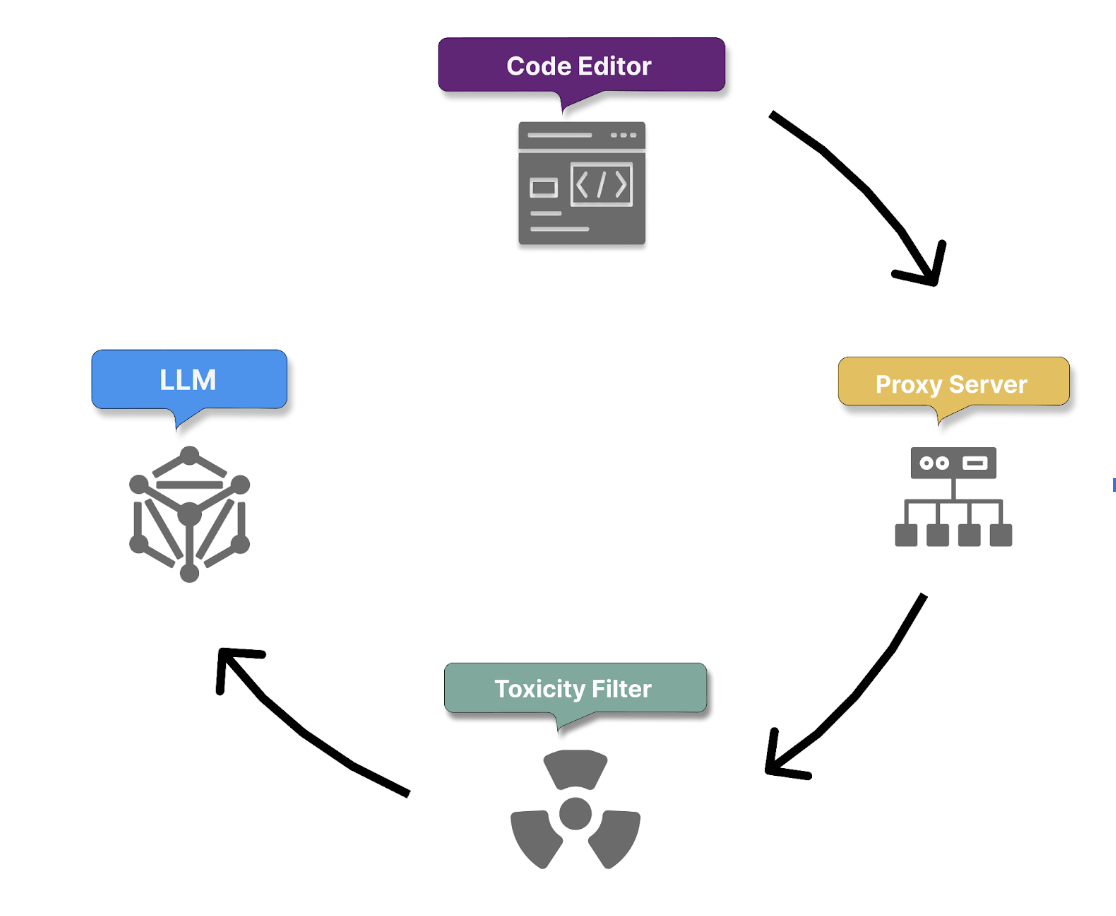

Let's walk through all the steps Copilot takes to process a user's prompt into a code suggestion.

### 1. Secure prompt transmission and context gathering

The process begins with the **secure transmission of the user prompt over HTTPS**. This ensures that your natural language comment is sent to GitHub Copilot's servers securely and confidentially, protecting sensitive information.

GitHub Copilot securely receives the user prompt, which could be a Copilot chat or a natural language comment provided by you within your code.

Simultaneously, **Copilot collects context details**:
* Code before and after the cursor position, which helps it understand the immediate context of the prompt.
* Filename and type of the file being edited, allowing it to tailor code suggestions to the specific file type.
* Information about adjacent open tabs, ensuring that the generated code aligns with other code segments in the same project.
* Information on project structure and file paths
* Information on programming languages and frameworks
* Pre-processing using Fill-in-the-Middle (FIM) technique to consider both the preceding and following code context, effectively expanding the model's understanding allowing Copilot to generate more accurate and relevant code suggestions by leveraging a broader context.

These steps translate the user's high-level request into a concrete coding task.

### 2. Proxy filter

Once the context is gathered and the prompt is built, it passes securely to a proxy server hosted in a GitHub-owned Microsoft Azure tenant. The proxy filters traffic, blocking attempts to hack the prompt or manipulate the system into revealing details about how the model generates code suggestions.

### 3. Toxicity filtering

Copilot incorporates content filtering mechanisms before proceeding with intent extraction and code generation, to ensure that the generated code and responses don't include or promote:
* **Hate speech and inappropriate content**: Copilot employs algorithms to detect and prevent the intake of hate speech, offensive language, or inappropriate content that could be harmful or offensive.
* **Personal data**: Copilot actively filters out any personal data, such as names, addresses, or identification numbers, to protect user privacy and data security.

### 4. Code generation with LLM

Finally, the filtered and analyzed prompt is passed to LLM Models, which generate appropriate code suggestions. These suggestions are based on Copilot’s understanding of the prompt and the surrounding context, ensuring that the generated code is relevant, functional, and aligned with project-specific requirements.

## Outbound Flow:

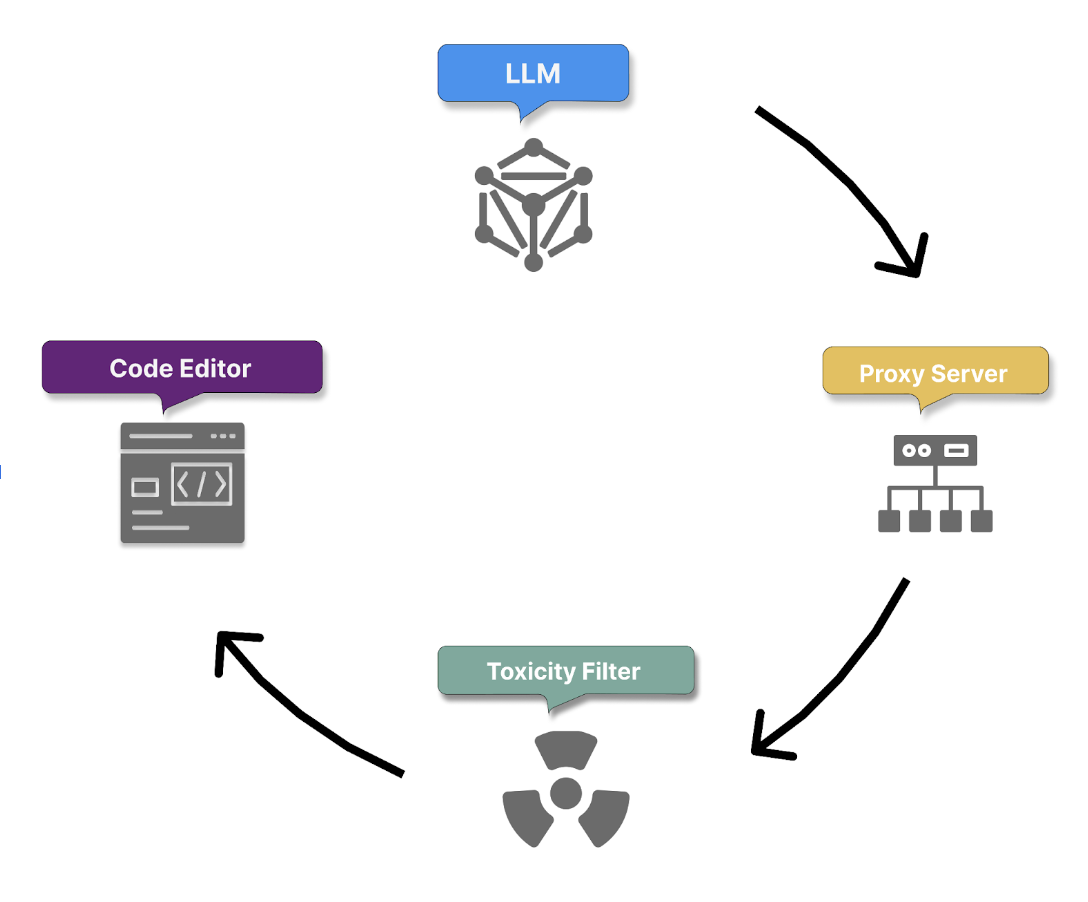

### 5. Post-processing and response validation

Once the model produces its responses, the toxicity filter removes any harmful or offensive generated content. The proxy server then applies a final layer of checks to ensure code quality, security, and ethical standards. These checks include:
* **Code quality**: Responses are checked for common bugs or vulnerabilities, such as cross-site scripting (XSS) or SQL injection, ensuring that the generated code is robust and secure.
* **Matching public code (optional)**: Optionally, administrators can enable a filter that prevents Copilot from returning suggestions over ~150 characters if they closely resemble existing public code on GitHub. This prevents coincidental matches from being suggested as original content. If any part of the response fails these checks, it is either truncated or discarded.

### 6. Suggestion delivery and feedback loop initiation

Only responses that pass all filters are delivered to the user. Copilot then initiates a feedback loop based on your actions to achieve the following:
* Grow its knowledge from accepted suggestions.
* Learn and improve through modifications and rejections of its suggestions.

### 7. Repeat for subsequent prompts

The process is repeated as you provide more prompts, with Copilot continuously handling user requests, understanding their intent, and generating code in response. Over time, Copilot applies the cumulative feedback and interaction data, including context details, to improve its understanding of user intent and refine its code generation capabilities.

# GitHub Copilot data

In this unit, we'll cover how GitHub Copilot handles data for different environments, features and configurations.

## Data handling for GitHub Copilot code suggestions

GitHub Copilot in the code editor does not retain any prompts like code or other context used for the purposes of providing suggestions to train the foundational models. It discards the prompts once a suggestion is returned.

GitHub Copilot Individual subscribers can opt-out of sharing their prompts with GitHub which will otherwise be used to finetune GitHub’s foundational model.

## Data handling for GitHub Copilot chat

GitHub Copilot Chat operates as an interactive platform, allowing developers to engage in conversational interactions with the AI assistant to receive coding assistance. 

Here are the steps that it carries out which might be distinct from other features like code completion:
* **Formatting**: Copilot meticulously formats the generated response for optimal presentation within the chat interface. It highlights code snippets to improve readability and may include options for direct integration into your code. Copilot showcases the formatted response in the Copilot Chat window within the IDE, allowing you to easily review and interact with the provided information.
* **User engagement**: You can actively engage with the response by asking follow-up questions, requesting clarifications, or providing additional input. The chat interface maintains a conversation history to facilitate contextual understanding in subsequent interactions.
* **Data retention**: For Copilot Chat used outside the code editor, GitHub typically retains prompts, suggestions, and supporting context for **28 days**. Specific retention policies for Copilot Chat within the code editor may vary.

The same goes for CLI, Mobile, and GitHub Copilot Chat on GitHub.com.

## Prompt types supported by GitHub Copilot Chat

GitHub Copilot Chat processes a wide range of coding-related prompts, demonstrating its versatility as a conversational coding assistant. Here are some common input types:

* **Direct Questions**: You can ask specific questions about coding concepts, libraries, or troubleshooting issues. For example:
    * How do I implement a quick sort algorithm in Python? 
    * Why is my React component not rendering?
* **Code-Related Requests**: You can request code generation, modification, or explanation. Examples includes:
    * Write a function to calculate factorial.
    * Fix this error in my code.
    * Explain this code snippet.
* **Open-Ended Queries**: You can explore coding concepts or seek general guidance by asking open-ended questions like:
    * What are the best practices for writing clean code?
    * How can I improve the performance of my Python application?
* **Contextual Prompts**: You can provide code snippets or describe specific coding scenarios to seek tailored assistance. For instance:
    * Here's a part of my code, can you suggest improvements?
    * I'm building a web application, can you help me with the authentication flow?

Copilot Chat's ability to process diverse input types enhances its utility as a comprehensive coding companion.

## Limited context windows

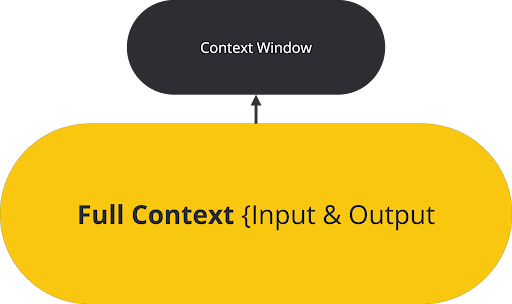

While GitHub Copilot Chat excels at understanding and responding to prompts, it's essential to acknowledge the **limitation of context windows**. 
* This refers to the amount of surrounding code and text the model can process simultaneously to generate suggestions.
* GitHub Copilot's context window typically ranges from approximately 200-500 lines of code or up to a few thousand tokens.
* This limitation can vary depending on the specific implementation and version of Copilot being used.

Copilot Chat currently operates with a context window of 4k tokens, providing a broader scope for understanding and responding to user queries compared to the standard Copilot.

Despite these advancements, you should be mindful of context window limitations when crafting prompts. Breaking down complex problems into smaller, more focused queries or providing relevant code snippets can significantly enhance the model's ability to provide accurate and helpful responses.

# GitHub Copilot Large Language Models (LLMs)

GitHub Copilot is powered by Large Language Models (LLMs) to assist you in writing code seamlessly. In this unit, we focus on understanding the integration and impact of LLMs in GitHub Copilot. 

Let's review the following topics:
* What are LLMs?
* The role of LLMs in GitHub Copilot and prompting
* Fine-tuning LLMs
* LoRA fine-tuning

## What are LLMs?

Large Language Models (LLMs) are artificial intelligence models designed and trained to understand, generate, and manipulate human language. These models are ingrained with the capability to handle a broad range of tasks involving text, thanks to the extensive amount of text data they're trained on. 

Here are some core aspects to understand about LLMs:

**Volume of training data**
* LLMs are exposed to vast amounts of text from diverse sources.
* This exposure equips them with a broad understanding of language, context, and intricacies involved in various forms of communication.

**Contextual understanding**
* They excel in generating contextually relevant and coherent text.
* Their ability to understand context allows them to provide meaningful contributions, be it completing sentences, paragraphs, or even generating whole documents that are contextually apt.

**Machine learning and AI integration**
* LLMs are grounded in machine learning and artificial intelligence principles.
* They're neural networks with millions, or even billions, of parameters that are fine-tuned during the training process to understand and predict text effectively.

**Versatility**
* These models aren't limited to a specific type of text or language.
* They can be tailored and fine-tuned to perform specialized tasks, making them highly versatile and applicable across various domains and languages.

## Role of LLMs in GitHub Copilot and prompting

GitHub Copilot utilizes LLMs to provide context-aware code suggestions. The LLM considers not just the current file but also other open files and tabs in the IDE to generate accurate and relevant code completions. This dynamic approach ensures tailored suggestions, improving your productivity.

## Fine-tuning LLMs

Fine-tuning is a critical process that allows us to tailor pretrained large language models (LLMs) for specific tasks or domains. It involves training the model on a smaller, task-specific dataset, known as the target dataset, while using the knowledge and parameters gained from a large pretrained dataset, referred to as the source model.

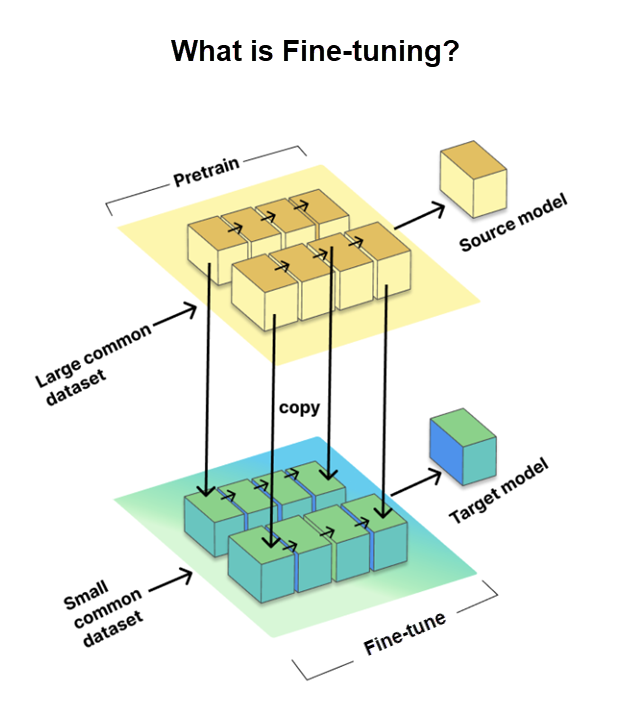

Fine-tuning is essential to adapt LLMs for specific tasks, enhancing their performance. However, GitHub took it a step further by using the LoRA fine tuning method, which we discuss next.

## LoRA (Low-Rank Adaptation) fine-tuning

Traditional full fine-tuning means to train all parts of a neural network, which can be slow and heavily reliant on resources. But **LoRA (Low-Rank Adaptation)** fine-tuning is a clever alternative. It's used to make large pretrained language models (LLMs) work better for specific tasks without redoing all the training.

Here's how LoRA works:
* **LoRA** adds smaller trainable parts to each layer of the pretrained model, instead of changing everything.
* The original model remains the same, which saves time and resources.

What's great about LoRA:
* It beats other adaptation methods like adapters and prefix-tuning.
* It's like getting great results with fewer moving parts.

In simple terms, LoRA fine-tuning is about working smarter, not harder, to make LLMs better for your specific coding requirements when using Copilot.